In [1]:
import imageio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import os
import numpy as np
import tifffile as tiff
import matplotlib
matplotlib.use('TkAgg')

In [17]:
#Load your TIFFs
pre_pathA = "/Volumes/DullaLab$/Rebecca S/Projects/LTP/08062024/slice2/Averaged_Normalized_Output_pre_channel1.tiff"
post_pathA = "/Volumes/DullaLab$/Rebecca S/Projects/LTP/08062024/slice2/Averaged_Normalized_Output_post_channel1.tiff"

pre_pathN = "/Volumes/DullaLab$/Rebecca S/Projects/LTP/08062024/slice2/Averaged_Normalized_Output_pre_channel2.tiff"
post_pathN = "/Volumes/DullaLab$/Rebecca S/Projects/LTP/08062024/slice2/Averaged_Normalized_Output_post_channel2.tiff"

In [18]:
pre_tiffA = imageio.mimread(pre_pathA)
post_tiffA = imageio.mimread(post_pathA)

pre_tiffN = imageio.mimread(pre_pathN)
post_tiffN = imageio.mimread(post_pathN)

In [25]:
pre_tiffA = np.array(pre_tiffA[2:83])
post_tiffA = np.array(post_tiffA[2:83])

pre_tiffN = np.array(pre_tiffN[2:83])
post_tiffN = np.array(post_tiffN[2:83])

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Ensure inline plotting in Jupyter Notebook
%matplotlib inline

def process_data(tiff_array, roi_coords, zscore=True):
    """Processes TIFF array and returns the Z-scored mean trace."""
    
    if roi_coords:
        x_start, x_end, y_start, y_end = roi_coords
        roi_avg_intensity = []

        for frame in tiff_array:
            roi = frame[y_start:y_end, x_start:x_end]
            avg_intensity = np.mean(roi)
            roi_avg_intensity.append(avg_intensity)

        roi_avg_intensity = np.array(roi_avg_intensity)

        if zscore:
            mean_intensity = np.mean(roi_avg_intensity)
            std_intensity = np.std(roi_avg_intensity)
            processed_intensity = (roi_avg_intensity - mean_intensity) / std_intensity
        else:
            processed_intensity = roi_avg_intensity

        return processed_intensity
    else:
        print("No ROI coordinates provided.")
        return None

def plot_combined(pre_tiffA, post_tiffA, pre_tiffN, post_tiffN, roi_coords):
    """Plots pre-sweep and post-sweep data for both conditions on the same plot."""
    pre_mean_traceA = process_data(pre_tiffA, roi_coords, zscore=False)
    post_mean_traceA = process_data(post_tiffA, roi_coords, zscore=False)
    pre_mean_traceN = process_data(pre_tiffN, roi_coords, zscore=False)
    post_mean_traceN = process_data(post_tiffN, roi_coords, zscore=False)
    
    if pre_mean_traceA is not None and post_mean_traceA is not None and pre_mean_traceN is not None and post_mean_traceN is not None:
        frame_indices = np.arange(len(pre_mean_traceA))

        plt.figure(figsize=(12, 8))

        # Plot pre-sweep A
        plt.plot(frame_indices, pre_mean_traceA, label='Pre-Sweep Mean Intensity', color='green')

        # Plot post-sweep A
        plt.plot(frame_indices, post_mean_traceA, label='Post-Sweep Mean Intensity)', color='lightgreen')
        #Plot pre-sweep N
        # plt.plot(frame_indices, pre_mean_traceN, label='Pre-Sweep N Mean Intensity', color='pink')
        #
        # # Plot post-sweep N
        # plt.plot(frame_indices, post_mean_traceN, label='Post-Sweep N Mean Intensity', color='red')

        plt.xlabel('Frame Index')
        plt.ylabel('Average Pixel Intensity')
        plt.title('Mean ROI Average Pixel Intensity (GEVI)')
        plt.grid(False)
        plt.legend()
        plt.show()
    else:
        print("Error processing data.")

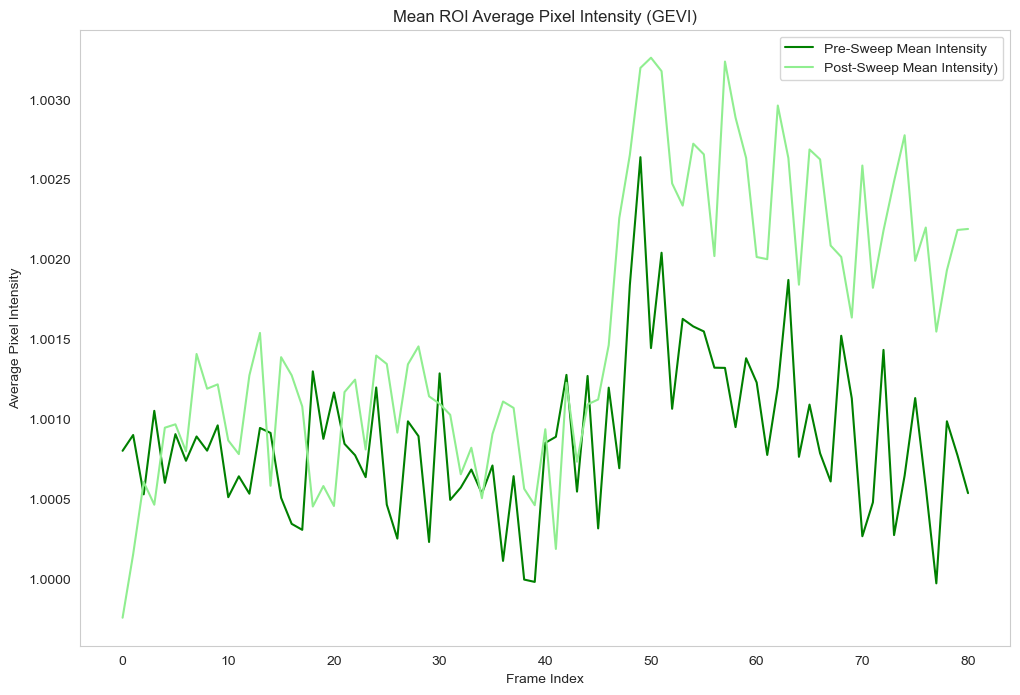

In [34]:

# Define your ROI coordinates here
roi_coords = [25,37,19,31]

# Example usage
plot_combined(pre_tiffA, post_tiffA, pre_tiffN, post_tiffN, roi_coords)


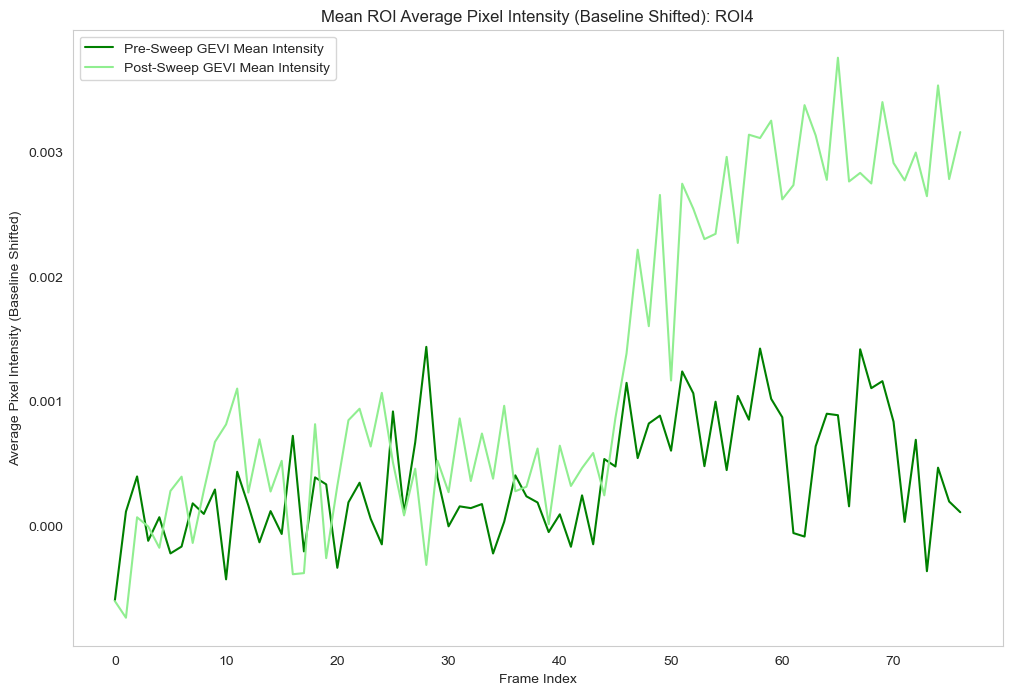

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Ensure inline plotting in Jupyter Notebook
%matplotlib inline

def process_data(tiff_array, roi_coords, zscore=True):
    """Processes TIFF array and returns the Z-scored mean trace."""
    
    if roi_coords:
        x_start, x_end, y_start, y_end = roi_coords
        roi_avg_intensity = []

        for frame in tiff_array:
            roi = frame[y_start:y_end, x_start:x_end]
            avg_intensity = np.mean(roi)
            roi_avg_intensity.append(avg_intensity)

        roi_avg_intensity = np.array(roi_avg_intensity)

        if len(roi_avg_intensity) > 4:
            roi_avg_intensity = roi_avg_intensity[2:-2]
        else:
            print(f"Not enough frames to remove 2 indices from start and end.")
            return None

        if zscore:
            mean_intensity = np.mean(roi_avg_intensity)
            std_intensity = np.std(roi_avg_intensity)
            processed_intensity = (roi_avg_intensity - mean_intensity) / std_intensity
        else:
            processed_intensity = roi_avg_intensity

        return processed_intensity
    else:
        print("No ROI coordinates provided.")
        return None

def baseline_shift(trace):
    """Shifts the baseline of the trace to 0."""
    baseline = np.mean(trace[:10])  # You can adjust this if you have a specific baseline period
    return trace - baseline

def plot_combined(pre_tiffA, post_tiffA, pre_tiffN, post_tiffN, roi_coords):
    """Plots pre-sweep and post-sweep data for both conditions on the same plot."""
    pre_mean_traceA = process_data(pre_tiffA, roi_coords, zscore=False)
    post_mean_traceA = process_data(post_tiffA, roi_coords, zscore=False)
    pre_mean_traceN = process_data(pre_tiffN, roi_coords, zscore=False)
    post_mean_traceN = process_data(post_tiffN, roi_coords, zscore=False)
    
    if pre_mean_traceA is not None and post_mean_traceA is not None and pre_mean_traceN is not None and post_mean_traceN is not None:
        # Baseline shift
        pre_mean_traceA = baseline_shift(pre_mean_traceA)
        post_mean_traceA = baseline_shift(post_mean_traceA)
        # pre_mean_traceN = baseline_shift(pre_mean_traceN)
        # post_mean_traceN = baseline_shift(post_mean_traceN)
        
        frame_indices = np.arange(len(pre_mean_traceA))

        plt.figure(figsize=(12, 8))

        # Plot pre-sweep A
        plt.plot(frame_indices, pre_mean_traceA, label='Pre-Sweep GEVI Mean Intensity', color='green')

        # Plot post-sweep A
        plt.plot(frame_indices, post_mean_traceA, label='Post-Sweep GEVI Mean Intensity', color='lightgreen')

        # Plot pre-sweep N
        # plt.plot(frame_indices, pre_mean_traceN, label='Pre-Sweep N-XCaMP Mean Intensity', color='red')
        #
        # # Plot post-sweep N
        # plt.plot(frame_indices, post_mean_traceN, label='Post-Sweep N-XCaMP Mean Intensity)', color='pink')

        plt.xlabel('Frame Index')
        plt.ylabel('Average Pixel Intensity (Baseline Shifted)')
        plt.title('Mean ROI Average Pixel Intensity (Baseline Shifted): ROI4')
        plt.grid(False)
        plt.legend()
        plt.show()
    else:
        print("Error processing data.")

    return pre_mean_traceA, pre_mean_traceN

# Define your ROI coordinates here
roi_coords = [59,70,31,43]

# Example usage
pre_mean_traceA, pre_mean_traceN = plot_combined(pre_tiffA, post_tiffA, pre_tiffN, post_tiffN, roi_coords)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


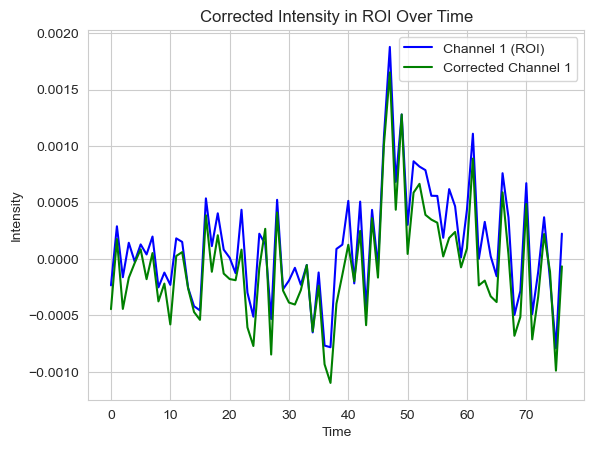

Slope (Bleedthrough Coefficient): 0.1949491834975851
Intercept: 0.0001557939352944625
R-squared: 0.021570721801061836


In [37]:
import scipy.stats as stats
# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(pre_mean_traceA, pre_mean_traceN)

# Calculate the bleedthrough contribution and correct Channel 1
bleedthrough_contribution = slope * pre_mean_traceN + intercept
corrected_signal = pre_mean_traceA - bleedthrough_contribution

# Plot the corrected signal
plt.figure()
plt.plot(pre_mean_traceA, label='Channel 1 (ROI)', color='blue')
# plt.plot(pre_mean_traceN, label='Channel 2 (ROI)', color='red')
plt.plot(corrected_signal, label='Corrected Channel 1', color='green')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.title('Corrected Intensity in ROI Over Time')
plt.show()

# Print regression parameters
print(f"Slope (Bleedthrough Coefficient): {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

# Initialize variables for storing the ROI coordinates
roi_coords = []

def line_select_callback(eclick, erelease):
    """Callback function to capture the ROI coordinates."""
    global roi_coords
    x1, y1 = int(eclick.xdata), int(eclick.ydata)
    x2, y2 = int(erelease.xdata), int(erelease.ydata)
    roi_coords = [min(x1, x2), max(x1, x2), min(y1, y2), max(y1, y2)]
    print(f"ROI selected: {roi_coords}")

def toggle_selector(event):
    """Toggle the selector tool with a key press (use 'Q' to quit selection)."""
    if event.key in ['Q', 'q'] and toggle_selector.RS.active:
        toggle_selector.RS.set_active(False)
        print("Selector deactivated")

# Display the first frame of pre_tiff for ROI selection
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(pre_tiff[3], cmap='gray')
ax.set_title("Select ROI with the mouse. Press 'Q' to confirm.")
toggle_selector.RS = RectangleSelector(ax, line_select_callback,
                                       button=[1], minspanx=10, minspany=10,
                                       spancoords='pixels', interactive=True)
plt.connect('key_press_event', toggle_selector)
plt.show()

# Check ROI coordinates before proceeding
print(f"ROI coordinates before processing: {roi_coords}")

# Function to calculate average intensity within the ROI
def calculate_roi_avg_intensity(tiff_stack, roi_coords):
    x_start, x_end, y_start, y_end = roi_coords
    roi_avg_intensity = []
    for frame in tiff_stack:
        roi = frame[y_start:y_end, x_start:x_end]
        avg_intensity = np.mean(roi)
        roi_avg_intensity.append(avg_intensity)
    return np.array(roi_avg_intensity)

# Calculate average intensity for both pre_tiff and post_tiff
if roi_coords:
    pre_tiff_avg_intensity = calculate_roi_avg_intensity(pre_tiff, roi_coords)
    post_tiff_avg_intensity = calculate_roi_avg_intensity(post_tiff, roi_coords)
    
    frame_indices = np.arange(len(pre_tiff_avg_intensity))

    plt.figure(figsize=(10, 6))
    plt.plot(frame_indices, pre_tiff_avg_intensity, label='Pre-TIFF ROI Average Intensity')
    plt.plot(frame_indices, post_tiff_avg_intensity, label='Post-TIFF ROI Average Intensity')
    plt.xlabel('Frame Index')
    plt.ylabel('Average Pixel Intensity')
    plt.title('ROI Average Pixel Intensity Across Time')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No ROI selected.")


ROI selected: [106, 125, 118, 138]
Selector deactivated
ROI coordinates before processing: [106, 125, 118, 138]


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

# Initialize a list to store the ROI coordinates
roi_coords_list = []

def line_select_callback(eclick, erelease):
    """Callback function to capture the ROI coordinates."""
    x1, y1 = int(eclick.xdata), int(eclick.ydata)
    x2, y2 = int(erelease.xdata), int(erelease.ydata)
    roi_coords = [min(x1, x2), max(x1, x2), min(y1, y2), max(y1, y2)]
    roi_coords_list.append(roi_coords)
    print(f"ROI selected: {roi_coords}")

def toggle_selector(event):
    """Toggle the selector tool with a key press (use 'Q' to quit selection)."""
    if event.key in ['Q', 'q'] and toggle_selector.RS.active:
        toggle_selector.RS.set_active(False)
        print("Selector deactivated")

# Display the first frame of pre_tiff for ROI selection
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(pre_tiff[0], cmap='gray')
ax.set_title("Select ROIs with the mouse. Press 'Q' to finish.")
toggle_selector.RS = RectangleSelector(ax, line_select_callback,
                                       button=[1], minspanx=10, minspany=10,
                                       spancoords='pixels', interactive=True)
plt.connect('key_press_event', toggle_selector)
plt.show()

# Check ROI coordinates before proceeding
print(f"ROI coordinates before processing: {roi_coords_list}")

# Function to calculate average intensity within the ROI
def calculate_roi_avg_intensity(tiff_stack, roi_coords):
    x_start, x_end, y_start, y_end = roi_coords
    roi_avg_intensity = []
    for frame in tiff_stack:
        roi = frame[y_start:y_end, x_start:x_end]
        avg_intensity = np.mean(roi)
        roi_avg_intensity.append(avg_intensity)
    return np.array(roi_avg_intensity)

# Function to normalize the data using Z-score normalization
def zscore_normalize_data(data):
    return (data - np.mean(data)) / np.std(data)

# Calculate and plot Z-score normalized average intensity for each ROI
if roi_coords_list:
    plt.figure(figsize=(10, 6))

    for idx, roi_coords in enumerate(roi_coords_list):
        pre_tiff_avg_intensity = calculate_roi_avg_intensity(pre_tiff, roi_coords)
        post_tiff_avg_intensity = calculate_roi_avg_intensity(post_tiff, roi_coords)

        # Normalize the data using Z-score
        pre_tiff_avg_intensity = zscore_normalize_data(pre_tiff_avg_intensity)
        post_tiff_avg_intensity = zscore_normalize_data(post_tiff_avg_intensity)

        # Plot the Z-score normalized average pixel intensity across time for both pre_tiff and post_tiff
        frame_indices = np.arange(len(pre_tiff_avg_intensity))
        plt.plot(frame_indices, pre_tiff_avg_intensity, label=f'Pre-TIFF ROI {idx + 1} (Z-score)', linestyle='--')
        plt.plot(frame_indices, post_tiff_avg_intensity, label=f'Post-TIFF ROI {idx + 1} (Z-score)')

    plt.xlabel('Frame Index')
    plt.ylabel('Z-score Normalized Average Pixel Intensity')
    plt.title('Z-score Normalized ROI Average Pixel Intensity Across Time')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No ROI selected.")


ROI selected: [81, 102, 55, 74]
Selector deactivated
ROI coordinates before processing: [[81, 102, 55, 74]]
